In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler,PolynomialFeatures

## Data under standing

In [2]:
df=pd.read_csv("D:\Python programming\Data sets\Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
df.shape

(375, 6)

In [4]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [5]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Gender', 'Education Level', 'Job Title'], dtype='object')
Numerical Columns: Index(['Age', 'Years of Experience', 'Salary'], dtype='object')


In [6]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()
std_age = df['Age'].std()

print("Mean:", mean_age)
print("Median:", median_age)
print("Standard Deviation:", std_age)


Mean: 37.43163538873995
Median: 36.0
Standard Deviation: 7.069072938567494


In [7]:
gender_percent = df['Gender'].value_counts(normalize=True) * 100
print(gender_percent)


Gender
Male      52.010724
Female    47.989276
Name: proportion, dtype: float64


In [8]:
education_percent = df['Education Level'].value_counts(normalize=True) * 100
print(education_percent)

Education Level
Bachelor's    60.053619
Master's      26.273458
PhD           13.672922
Name: proportion, dtype: float64


## Data cleaning

In [9]:
nan_rows = df.isnull().all(axis=1).sum()
print(nan_rows)

2


In [10]:
df = df.dropna(how='all')

In [11]:
nan_rows = df.isnull().all(axis=1).sum()
print(nan_rows)

0


In [12]:
duplicates = df.duplicated().sum()
print(duplicates)

49


In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

0

In [15]:
df.reset_index(drop=True, inplace=True)

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Education Level'] = le.fit_transform(df['Education Level'])


In [17]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [18]:
top_jobs=df['Job Title'].value_counts().nlargest(3).index
print(top_jobs)

Index(['Director of Operations', 'Director of Marketing',
       'Senior Marketing Manager'],
      dtype='object', name='Job Title')


In [19]:
df['Job Title']=df['Job Title'].apply(lambda x: x if x in top_jobs else "Others")
print(df['Job Title'])

0                      Others
1                      Others
2                      Others
3                      Others
4                      Others
                ...          
319                    Others
320                    Others
321                    Others
322                    Others
323    Director of Operations
Name: Job Title, Length: 324, dtype: object


In [20]:

df=pd.get_dummies(df,columns=['Job Title'])

In [21]:
df.shape

(324, 9)

In [22]:
df.head()

,Age,Gender,Education Level,Years of Experience,Salary,Job Title_Director of Marketing,Job Title_Director of Operations,Job Title_Others,Job Title_Senior Marketing Manager
0,32.0,1,0,5.0,90000.0,False,False,True,False
1,28.0,0,1,3.0,65000.0,False,False,True,False
2,45.0,1,2,15.0,150000.0,False,False,True,False
3,36.0,0,0,7.0,60000.0,False,False,True,False
4,52.0,1,1,20.0,200000.0,False,False,True,False


In [23]:
cols = ['Job Title_Director of Marketing',
        'Job Title_Director of Operations',
        'Job Title_Others',
        'Job Title_Senior Marketing Manager'
        ]

df[cols] = df[cols].astype(int)

In [24]:
df.dtypes

Age                                   float64
Gender                                  int32
Education Level                         int32
Years of Experience                   float64
Salary                                float64
Job Title_Director of Marketing         int32
Job Title_Director of Operations        int32
Job Title_Others                        int32
Job Title_Senior Marketing Manager      int32
dtype: object

## Exploratory Data Analysis (EDA)

In [25]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Years of Experience', 'Salary',
       'Job Title_Director of Marketing', 'Job Title_Director of Operations',
       'Job Title_Others', 'Job Title_Senior Marketing Manager'],
      dtype='object')

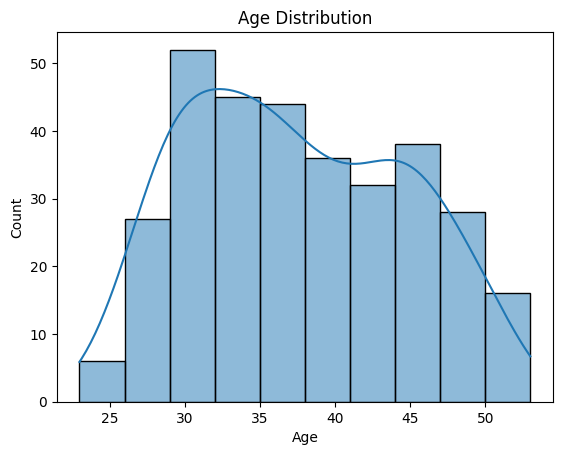

In [26]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [27]:
print(df['Age'].skew())

0.19520171937495945


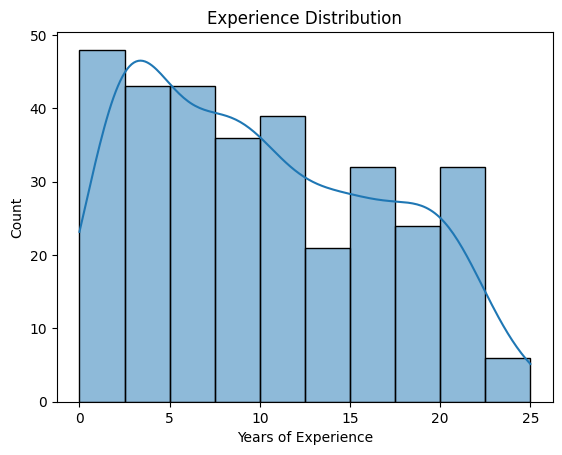

In [28]:
sns.histplot(df['Years of Experience'], kde=True)
plt.title("Experience Distribution")
plt.show()

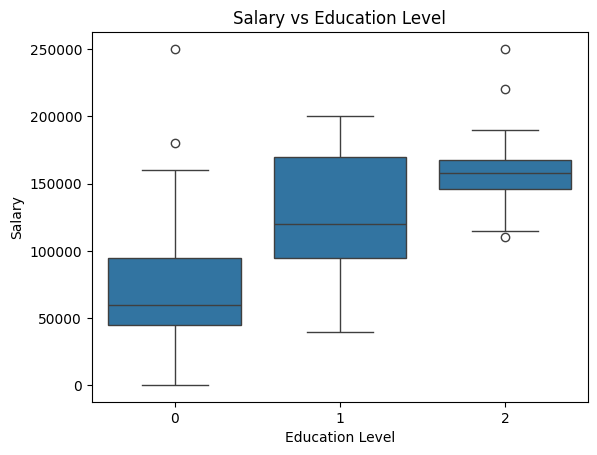

In [29]:
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.title("Salary vs Education Level")
plt.show()


In [30]:
avg_salary_gender = df.groupby('Gender')['Salary'].mean()
print(avg_salary_gender)


Gender
0     96136.363636
1    103472.647059
Name: Salary, dtype: float64


In [31]:
avg_salary_edu = df.groupby('Education Level')['Salary'].mean()
print(avg_salary_edu)

Education Level
0     73902.356021
1    127912.087912
2    158095.238095
Name: Salary, dtype: float64


In [32]:
exp_salary = df.groupby('Years of Experience')['Salary'].mean()
print(exp_salary)


Years of Experience
0.0      33333.333333
0.5      35000.000000
1.0      37857.142857
1.5      36395.454545
2.0      42115.384615
3.0      51296.296296
4.0      58125.000000
5.0      63750.000000
6.0      82272.727273
7.0      83750.000000
8.0      89117.647059
9.0     101842.105263
10.0     99375.000000
11.0    101111.111111
12.0    103214.285714
13.0    119000.000000
14.0    123181.818182
15.0    129166.666667
16.0    157666.666667
17.0    143000.000000
18.0    146818.181818
19.0    165769.230769
20.0    168846.153846
21.0    172727.272727
22.0    160000.000000
23.0    177500.000000
24.0    250000.000000
25.0    200000.000000
Name: Salary, dtype: float64


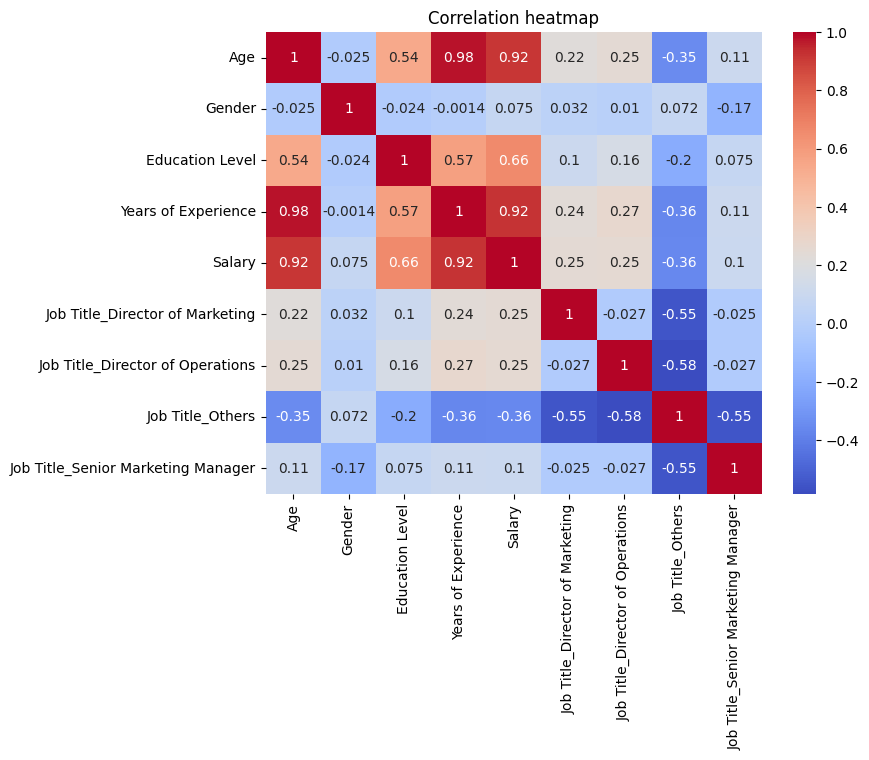

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

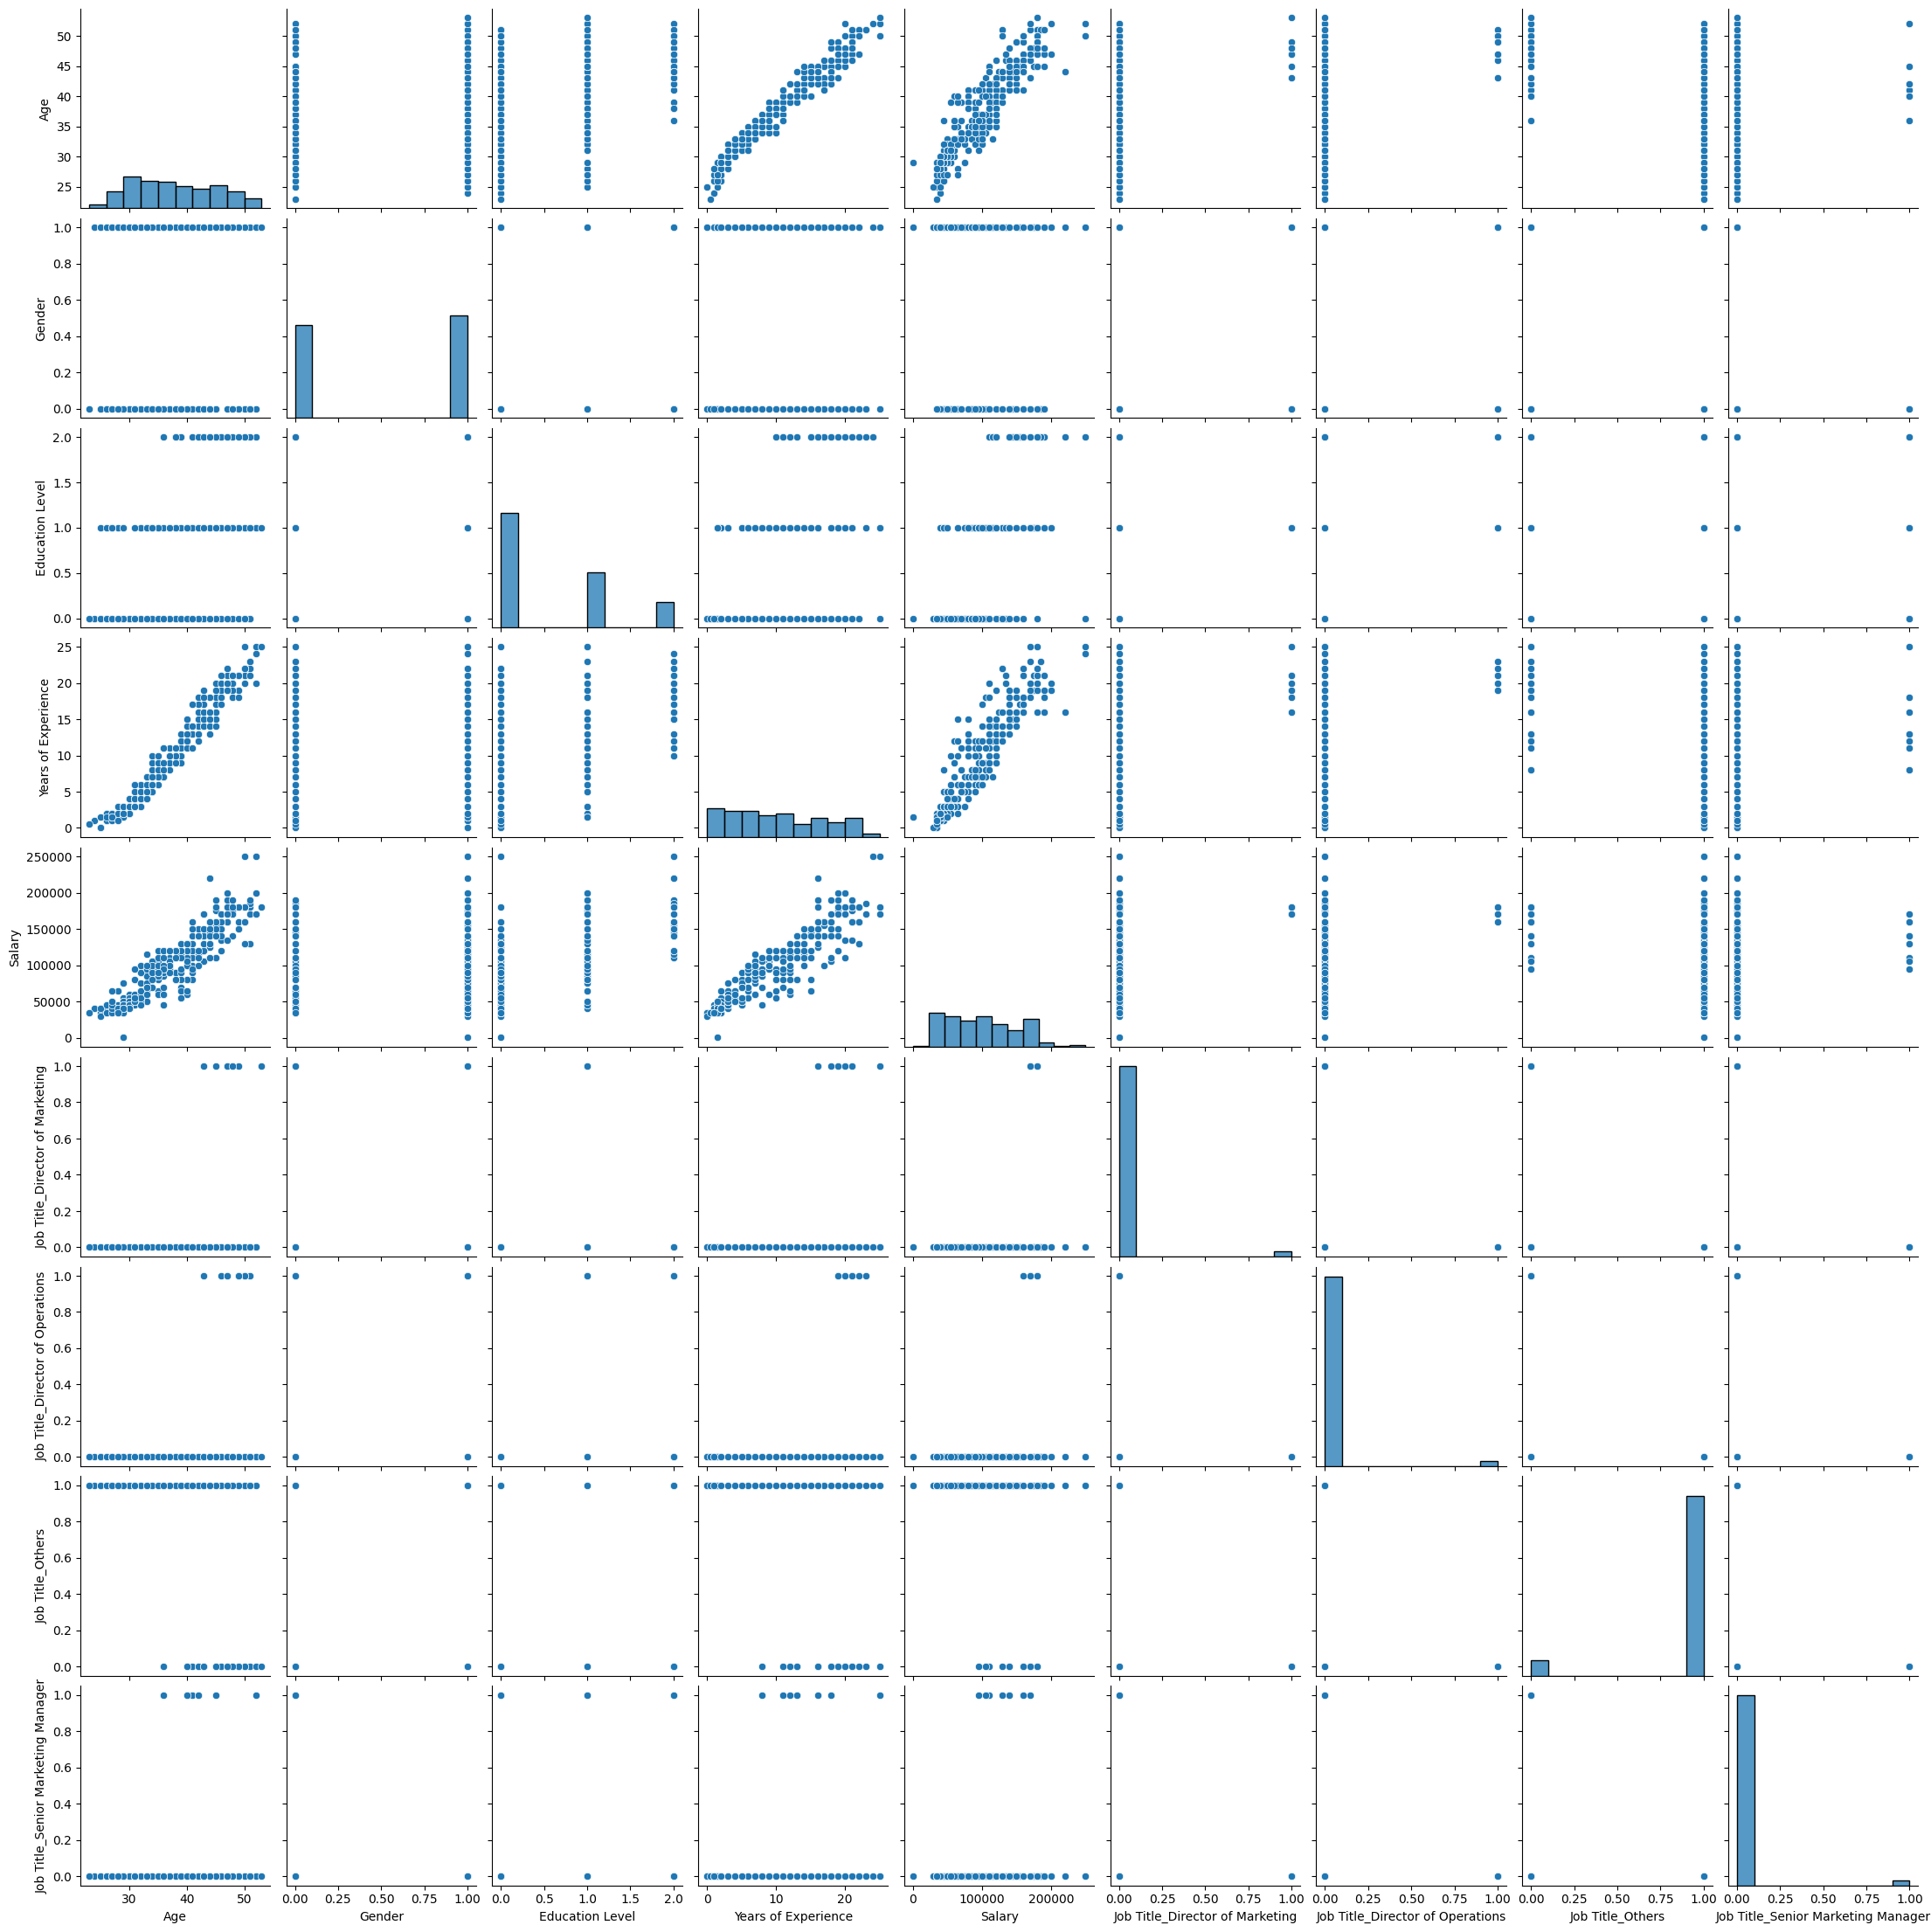

In [34]:
sns.pairplot(df)
plt.show()

## Model implementation

In [58]:
X=df.drop(df[['Age','Salary','Job Title_Senior Marketing Manager','Gender']],axis=1)
y=df['Salary']

In [59]:
X.columns

Index(['Education Level', 'Years of Experience',
       'Job Title_Director of Marketing', 'Job Title_Director of Operations',
       'Job Title_Others'],
      dtype='object')

In [60]:
# poly = PolynomialFeatures(degree=2, include_bias=False)  
# X_poly = poly.fit_transform(X)

In [61]:
scaler = StandardScaler()
X_poly_scaled= scaler.fit_transform(X_poly)

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X_poly_scaled,y,test_size=0.2, random_state=42)

In [63]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
y_pred =model.predict(X_test)

In [65]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 243825343.66143787
R2 Score: 0.8709773397997864


In [68]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

15614.907737845839


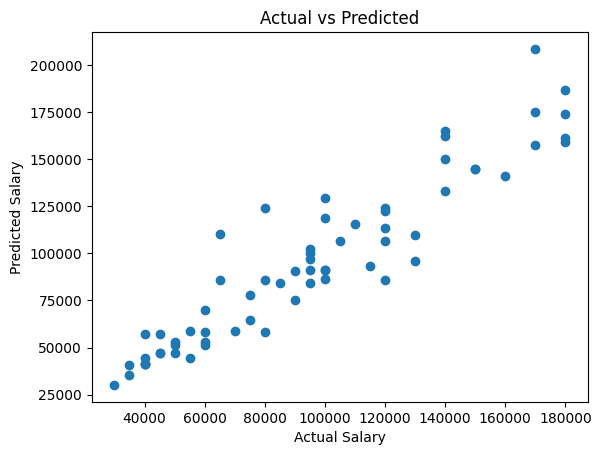

In [69]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

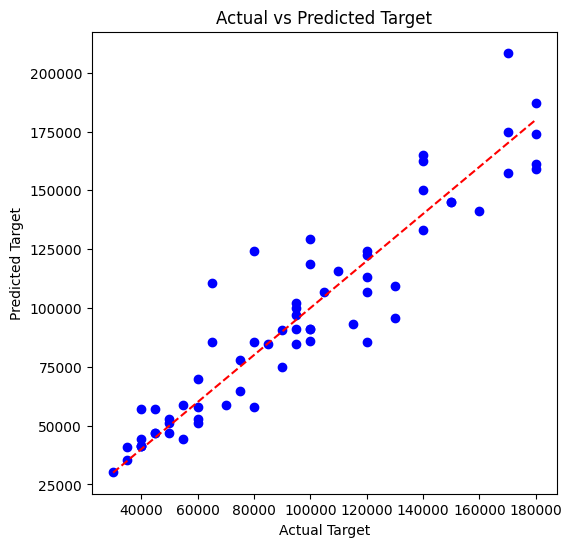

In [66]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted Target")
plt.show()

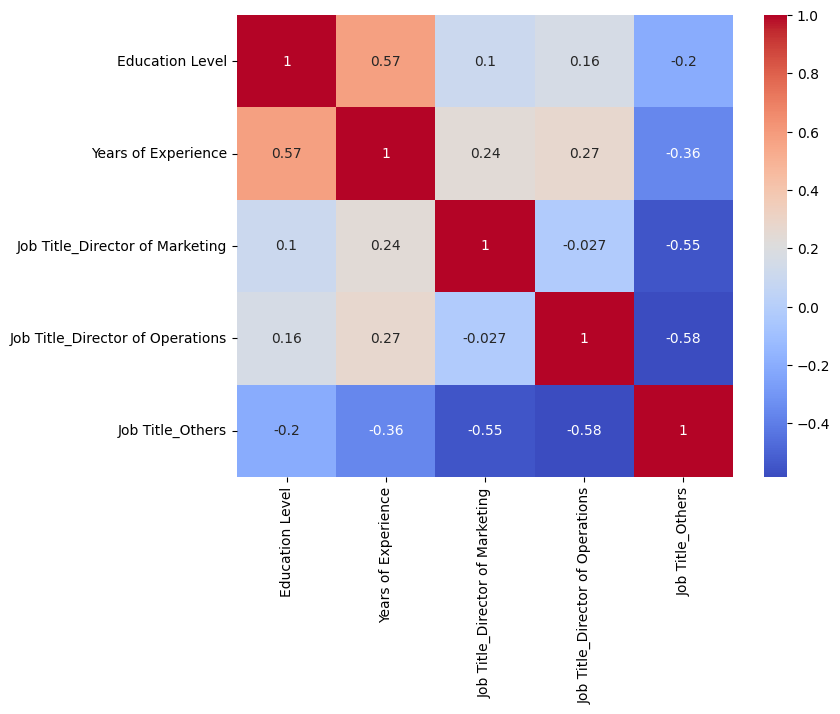

In [67]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.show()